# US Firm Characteristics: Cost Sensitivity

**Chapter 18 - Transaction Costs and Execution**

Every Sharpe reported so far is net of one cost assumption: the commission and
slippage `setup.yaml` declares, charged on turnover at each rebalance. That is a
single number standing in for the whole of execution, and it was picked before any
of these strategies existed. This notebook asks what the result would have been had
that number been wrong.

The question is not whether costs matter but *how fast* the result decays as they
rise. A strategy whose Sharpe falls slowly across the grid is one whose edge is
large relative to what it pays to trade, and it can survive being wrong about
execution. One that falls off a cliff is being carried by the cost assumption
rather than by the signal, and the assumption is then the finding.

The declared level sits inside the swept range rather than at its edge, so the
curve shows the result both above and below what the other notebooks charged.

Sections 1-2 write cost-sensitivity backtests to the registry. Section 3 is
read-only and reads them back.

**Book Reference:** Chapter 18, Sections 18.2-18.5

**Prerequisites:** the Chapter 16 backtest, the Chapter 17 allocation notebook and
[`13_risk_management`](13_risk_management.ipynb). Cost sensitivity runs last of the
selection stages: it sweeps the configuration the case study reports, which is chosen
across the baseline, allocation and risk-overlay stages together, so risk management
runs before it rather than after.

In [1]:
"""US Firm Characteristics: Costs."""

import json
import time
import warnings
from collections import Counter

import polars as pl

from utils.style import COLORS, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

from case_studies.utils.backtest_loaders import get_backtest_config, load_backtest_prices_for
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    ensure_backtest_spec,
    set_backtest_costs_bps,
    strategy_view,
)
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.registry import (
    backtest_dir,
    load_existing_backtest_hashes,
    read_predictions,
    resolve_best_backtest_runs,
)
from case_studies.utils.strategy_analysis import resolve_solvent_carrier
from case_studies.utils.sweep_config import get_cost_grid_bps
from utils.paths import get_case_study_dir

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
LABEL = ""
MAX_SYMBOLS = 0

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
if not LABEL:
    LABEL = bt_config.primary_label

print(f"Case study: {CASE_STUDY_ID}, label: {LABEL}")

COST_GRID_BPS = get_cost_grid_bps(CASE_STUDY_ID)

Case study: us_firm_characteristics, label: fwd_ret_1m


## 1. Which run is swept

The sweep runs one configuration: the one this case study reports. That is the
validation rank-1 `resolve_canonical_rank1_lineage` selects, and it is read here through
`resolve_solvent_carrier` rather than ranked again.

Ranking it again is what this notebook used to do, and a second ranking is not the same
selection even when it names the same stages. The canonical resolver re-ranks
`walk_forward_v2` conformal candidates on exact common timestamp support and applies
`LABEL_RESTRICTIONS`, `UNIVERSE_RESTRICTIONS` and `CARRIER_PINS`; a Sharpe ordering beside
it does none of those. Where the two disagreed, this notebook would sweep a strategy the
case study does not report, and [`15_strategy_analysis`](15_strategy_analysis.ipynb) would
find no cost rows for the one it does.

`resolve_solvent_carrier` also refuses a carrier whose equity reached zero. This book is
long-short with no margin call, so a run can compound through zero and carry a Sharpe
computed on a balance that no longer exists - and such a Sharpe can top a ranking. It
raises rather than quietly sweeping the runner-up, because substituting a different
configuration is the divergence the shared resolver exists to remove.

Which stage the carrier came from is printed rather than assumed.

In [4]:
carrier = resolve_solvent_carrier(CASE_STUDY_ID)

# The label is the carrier's, not the case study's declared primary. They are the same here,
# and reading it from the carrier is what keeps the prices and the predictions loaded below
# on the same label the swept configuration was fitted and ranked on.
if carrier["label"] != LABEL:
    print(f"Carrier is on {carrier['label']}, not the declared primary label {LABEL}.")
    LABEL = carrier["label"]

print(
    f"  Sharpe={carrier['val_sharpe']:.3f}  stage={carrier['val_stage']}  "
    f"family={carrier['family']}  config={carrier['config_name']}  "
    f"max_drawdown={carrier['max_drawdown']:.3f}  bt_hash={carrier['val_backtest_hash'][:8]}"
)

# Whether the overlay earned its place, reported rather than assumed. The risk stage files a
# row per named control and none for the un-overlaid strategy, so the two sides have to be
# read separately and differenced. A negative difference is the stage saying its controls did
# not help, which is a result and not a failure.
_best = {}
for _stage in ("risk_overlay", "allocation"):
    _frame = resolve_best_backtest_runs(
        CASE_STUDY_ID, LABEL, split="validation", stage=_stage, top_n=1
    )
    _best[_stage] = None if _frame.is_empty() else _frame["sharpe"][0]
if _best["risk_overlay"] is None:
    print(
        "  Risk overlay: no run registered, so the carrier above is un-overlaid. This "
        "case study declares position-level controls only and runs the vectorized "
        "path, where none of them can act."
    )
else:
    _delta = _best["risk_overlay"] - _best["allocation"]
    print(
        f"  Best overlaid {_best['risk_overlay']:.3f} vs best un-overlaid "
        f"{_best['allocation']:.3f}, difference {_delta:+.3f}"
    )

  Sharpe=3.063  stage=allocation  family=gbm  config=leaves_63_mse  max_drawdown=-0.101  bt_hash=2a0b06e4
  Risk overlay: no run registered, so the carrier above is un-overlaid. This case study declares position-level controls only and runs the vectorized path, where none of them can act.


In [5]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)
print(f"Prices: {len(prices):,} rows, {prices['symbol'].n_unique()} assets")

Prices: 252,008 rows, 3708 assets


## 2. Cost Grid Sweep

Each selected run is re-executed at every cost level in the declared grid, with
the level split evenly between commission and slippage. Nothing else about the
strategy changes, so the only thing separating one row from the next is what it
was charged to trade.

The grid and the strategy interact through turnover, which this panel keeps low by
rebalancing monthly: a cost level is paid once a month here rather than once a day,
so the same bps figure bites a monthly strategy far less than a daily one. That is
a property of the rebalance cadence, not a virtue of the signal, and it is the
reason the curve below can stay flat over a range that would destroy a
higher-frequency strategy.

A backtest hash covers the whole strategy spec, so a level already registered under
the same spec is served from the registry rather than recomputed. The summary below
reports two separate facts: what the stage contains, which is the same number whether
this execution was cold or warm and is what a reader needs, and what this execution
did, which is what a maintainer needs. Reported as one number they are
indistinguishable, and a warm re-run publishes a page claiming eleven backtests it
did not run.

The three execution counts sum to the levels attempted. `n_done` counts attempts, so a
failure has to come out of the computed figure or it is reported twice.

The reuse count asks `backtest_run_status`, which is the same call `run_backtest`
makes to decide, rather than checking the hash against a snapshot of the registry
taken before the loop. The two differ where a row is registered but has no
`daily_returns.parquet`: the runner recomputes it and a snapshot reports it as
reused, which is wrong in the direction that hides work.

`run_backtest` fills allocator defaults inside the call, so a hash built from the
spec this notebook holds is not necessarily the registered one. The set is keyed on
the hash the runner returns.

In [6]:
n_total = len(COST_GRID_BPS)
n_done = 0
n_failed = 0
n_reused = 0
failures: Counter[str] = Counter()
swept_hashes: list[str] = []
reusable_before = {
    _hash
    for _hash in load_existing_backtest_hashes(CASE_STUDY_ID, stage="cost_sensitivity")
    if (backtest_dir(CASE_STUDY_ID, _hash) / "daily_returns.parquet").exists()
}
t0 = time.time()

pred_hash = carrier["val_prediction_hash"]
base_spec = ensure_backtest_spec(
    CASE_STUDY_ID,
    bt_config,
    json.loads(carrier["spec_json"]),
    prices=prices,
    prediction_hash=pred_hash,
    initial_cash=bt_config.initial_cash,
)
alloc_method = strategy_view(base_spec).get("allocation", {}).get("method", "equal_weight")
predictions = read_predictions(CASE_STUDY_ID, pred_hash)

for cost_bps in COST_GRID_BPS:
    n_done += 1

    spec = set_backtest_costs_bps(
        clone_backtest_spec(base_spec),
        commission_bps=cost_bps / 2,
        slippage_bps=cost_bps / 2,
    )
    spec["chapter"] = "ch18"

    try:
        result = run_backtest(
            CASE_STUDY_ID,
            pred_hash,
            spec,
            prices=prices,
            predictions=predictions,
            label=LABEL,
            register=True,
            initial_cash=bt_config.initial_cash,
            calendar=bt_config.calendar,
        )

        swept_hashes.append(result.backtest_hash)
        if result.backtest_hash in reusable_before:
            n_reused += 1
        print(
            f"  [{n_done}/{n_total}] {alloc_method} @ {cost_bps:g} bps: "
            f"Sharpe={result.metrics.get('sharpe', 0):.3f}"
        )
    except Exception as error:
        # Counted rather than swallowed: the summary below reports this count, and
        # the check after the loop refuses to go on when nothing was registered.
        n_failed += 1
        failures[f"{type(error).__name__}: {error}"] += 1
        print(
            f"  [{n_done}/{n_total}] {alloc_method} @ {cost_bps:g} bps: "
            f"FAILED - {type(error).__name__}: {error}"
        )

elapsed = time.time() - t0
stage_total = len(load_existing_backtest_hashes(CASE_STUDY_ID, stage="cost_sensitivity"))
print(f"\nCost-sensitivity stage: {stage_total} backtests registered.")
print(
    f"This execution: {n_done - n_reused - n_failed} computed, {n_reused} reused, "
    f"{n_failed} failed, over {n_done} of {n_total} declared levels "
    f"attempted in {elapsed:.0f}s."
)
for reason, count in failures.most_common():
    print(f"  {count:>3} x {reason[:150]}")

  SKIP backtest (complete (hash=ee606d1c20fe)) — reusing cached result
  [1/11] conformal_weighted @ 0 bps: Sharpe=2.942
  SKIP backtest (complete (hash=d051439f24ad)) — reusing cached result
  [2/11] conformal_weighted @ 1 bps: Sharpe=2.937
  SKIP backtest (complete (hash=70edc1ce6ee8)) — reusing cached result
  [3/11] conformal_weighted @ 2 bps: Sharpe=2.931
  SKIP backtest (complete (hash=66afedf67f08)) — reusing cached result
  [4/11] conformal_weighted @ 3 bps: Sharpe=2.925
  SKIP backtest (complete (hash=3877ba37244b)) — reusing cached result
  [5/11] conformal_weighted @ 5 bps: Sharpe=2.913
  SKIP backtest (complete (hash=1d14d87f2254)) — reusing cached result
  [6/11] conformal_weighted @ 7 bps: Sharpe=2.902
  SKIP backtest (complete (hash=d22d7722a20e)) — reusing cached result


  [7/11] conformal_weighted @ 10 bps: Sharpe=2.884
  SKIP backtest (complete (hash=27d32394adc3)) — reusing cached result
  [8/11] conformal_weighted @ 15 bps: Sharpe=2.855


  SKIP backtest (complete (hash=97201e5311b6)) — reusing cached result
  [9/11] conformal_weighted @ 20 bps: Sharpe=2.826
  SKIP backtest (complete (hash=ccda9a5d1da7)) — reusing cached result
  [10/11] conformal_weighted @ 30 bps: Sharpe=2.768
  SKIP backtest (complete (hash=3a6f5abf26f9)) — reusing cached result
  [11/11] conformal_weighted @ 50 bps: Sharpe=2.652

Cost-sensitivity stage: 22 backtests registered.
This execution: 0 computed, 11 reused, 0 failed, over 11 of 11 declared levels attempted in 0s.


Section 3 reads the registry rather than the loop above, so a sweep that wrote nothing
and one that wrote everything look identical from there: the curve would be drawn from
whatever an earlier run left behind. Counting the failures is not enough on its own,
so the count stops the notebook.

Any failure stops it, not only a total one. Section 3 tells the reader that every level
is printed and that the top of the grid is what decides whether the curve reaches zero
inside it, so a single missing level can be the one the section is about. A grid with a
hole in it is not a smaller grid.

In [7]:
if n_failed:
    raise RuntimeError(
        f"{n_failed} of {n_total} cost levels failed, so the grid section 3 renders is "
        "incomplete. Its prose tells the reader every level is shown and that the top of "
        "the grid decides whether the curve reaches zero inside it, and a missing level "
        "may be exactly that one - so a partial sweep is not a partial result here."
    )

## 3. Cost Sensitivity Analysis

This section is **read-only**: it reads the cost-sensitivity rows back out of the
registry.

What to look for in the curve is its slope, not its height. The height is the
Sharpe already reported by the earlier notebooks and inherits their selection. The
slope is new information, and it says how much of that Sharpe was a claim about
execution rather than about the signal. A curve that reaches zero inside the grid
names the cost level at which the strategy stops being worth trading; one that does
not reach zero says only that the level is somewhere beyond the range tested, which
is a weaker statement than it looks.

In [8]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)

The read is scoped to the backtests the sweep above registered, not to the prediction
they were run on. The cost-sensitivity table accumulates across runs and labels, and the
selection feeding this notebook moves whenever an upstream stage is re-run, so an
unscoped read pools the current curve with every curve that preceded it and draws them
as one series per allocator.

A prediction is not a strategy, so scoping by prediction is not enough here. The retired
`walk_forward_v2` conformal sweep and the `walk_forward_v3` one that replaced it were run
on the same prediction set, both are in the registry, and both are `conformal_weighted` -
so a read scoped by prediction returns twenty-two rows under one allocator name and draws
two generations as one line.

In [9]:
cost_df = explorer.cost_sensitivity(backtest_hashes=swept_hashes)

The figure below shows the slope; this is the curve it is drawn from. A reader
comparing a decay rate against their own estimate of what they would pay needs the
levels themselves, and reading them off a line is not the same as having them. Every
level is printed rather than polars' default ten, so the top of the grid - the level
that decides whether the curve reaches zero inside it - is never the row that is
elided.

In [10]:
if cost_df.is_empty():
    print("No cost sensitivity data in registry")
else:
    with pl.Config(tbl_rows=cost_df.height):
        print(cost_df.sort("allocator", "cost_bps"))

shape: (11, 4)
┌──────────┬──────────┬──────────────┬────────────────────┐
│ cost_bps ┆ sharpe   ┆ max_drawdown ┆ allocator          │
│ ---      ┆ ---      ┆ ---          ┆ ---                │
│ f64      ┆ f64      ┆ f64          ┆ str                │
╞══════════╪══════════╪══════════════╪════════════════════╡
│ 0.0      ┆ 2.9424   ┆ -0.095605    ┆ conformal_weighted │
│ 1.0      ┆ 2.936607 ┆ -0.096041    ┆ conformal_weighted │
│ 2.0      ┆ 2.930813 ┆ -0.096476    ┆ conformal_weighted │
│ 3.0      ┆ 2.925019 ┆ -0.096911    ┆ conformal_weighted │
│ 5.0      ┆ 2.913427 ┆ -0.097781    ┆ conformal_weighted │
│ 7.0      ┆ 2.901833 ┆ -0.09865     ┆ conformal_weighted │
│ 10.0     ┆ 2.884436 ┆ -0.099952    ┆ conformal_weighted │
│ 15.0     ┆ 2.855428 ┆ -0.102119    ┆ conformal_weighted │
│ 20.0     ┆ 2.826402 ┆ -0.104282    ┆ conformal_weighted │
│ 30.0     ┆ 2.7683   ┆ -0.108595    ┆ conformal_weighted │
│ 50.0     ┆ 2.651901 ┆ -0.117173    ┆ conformal_weighted │
└──────────┴──────────┴──

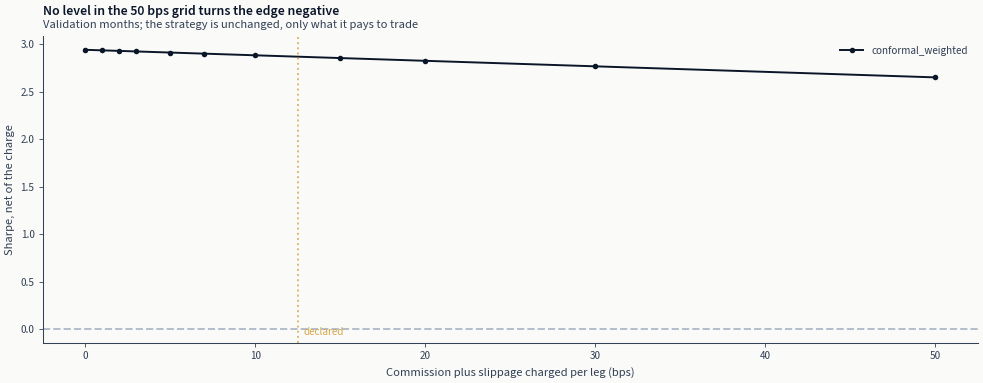

In [11]:
import matplotlib.pyplot as plt

if not cost_df.is_empty():
    fig, ax = plt.subplots(figsize=(10, 4))

    for alloc in cost_df["allocator"].unique().sort().to_list():
        subset = cost_df.filter(pl.col("allocator") == alloc).sort("cost_bps")
        ax.plot(subset["cost_bps"].to_list(), subset["sharpe"].to_list(), marker="o", label=alloc)

    ax.axhline(0, color=COLORS["recede"], linestyle="--", alpha=0.7)
    # The declared level, so the reader can see which part of the curve the rest of
    # the case study was run on and which part is the counterfactual.
    declared_bps = bt_config.commission_bps + bt_config.slippage_bps
    ax.axvline(declared_bps, color=COLORS["amber"], linestyle=":", alpha=0.8)
    ax.annotate(
        "declared",
        xy=(declared_bps, ax.get_ylim()[0]),
        xytext=(4, 6),
        textcoords="offset points",
        fontsize=8,
        color=COLORS["amber"],
    )
    ax.set_xlabel("Commission plus slippage charged per leg (bps)")
    ax.set_ylabel("Sharpe, net of the charge")
    add_message_title(
        ax,
        "No level in the 50 bps grid turns the edge negative",
        subtitle="Validation months; the strategy is unchanged, only what it pays to trade",
    )
    ax.legend(frameon=False)
    fig.tight_layout()
    show_with_alt(
        fig,
        "Line chart of validation Sharpe against the total commission and slippage "
        "charged per leg, from zero to fifty basis points. The line starts just under "
        "2.95 and falls almost straight to about 2.65 at the right edge, staying far "
        "above the dashed zero reference across the whole grid. A dotted vertical "
        "marker near the left shows the cost level the rest of the case study was "
        "charged at, with most of the swept range lying to its right.",
    )

## What this notebook establishes, and what it does not

The curve is a statement about one strategy, not about the surface. It re-runs the
single highest-Sharpe validation run at each cost level, so it answers how *that*
result would have moved had execution been priced differently. It does not say
whether a different strategy would have been chosen under a different cost
assumption, which is a larger question: the selection that produced this run was
itself made on results charged at the declared level.

The height of the curve carries the selection of every stage before it and should
not be read as an estimate of what the strategy would earn. The slope is the part
that is this notebook's own, and it is what the strategy analysis notebook uses.

These are validation months throughout. Nothing here reads or selects on the holdout
period, which stays untouched until the strategy analysis notebook.

**Next:** [`15_strategy_analysis`](15_strategy_analysis.ipynb), which reads this sweep
back alongside the holdout. Risk management is no longer next: it ran before this
notebook, and its result is one of the three stages the selection above drew from.